# Synthetic benchmark metrics analysis


This jupyter notebook analyzes the profiler metrics collected from the synthetic benchmark data. The goal is to understand the performance characteristics of the system under test and identify any potential bottlenecks or areas for optimization.

In [95]:
import sys
from typing import cast
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# import helper scripts from local directory
from helpers.visualization import save_or_show, format_elapsed_axis, color_for
from helpers.dataset import _get_components, _get_ecall_names, get_lifecycle_events

## Configuration

In [96]:
METRICS_CSV_DIR = Path("data/medium/single-worker/sws01")
OUTPUT_DIR = METRICS_CSV_DIR / "plots"
SAVE_PLOTS = False
PLOT_FORMAT = "png"

if not METRICS_CSV_DIR.is_dir():
    raise FileNotFoundError(f"Source directory does not exist: '{METRICS_CSV_DIR}'")

if SAVE_PLOTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_EPOCH_COLOR = "black" # color for the vertical line indicating MAX_EPOCH_REACHED in the plots

## Loading CSVs

In [97]:
def load_profiler_csvs(csv_dir: Path) -> pd.DataFrame:
    """Load and concatenate all profiler-*.csv files from the given directory."""
    files = sorted(csv_dir.glob("profiler-*.csv"))
    if not files:
        print(f"ERROR: No profiler-*.csv files found in '{csv_dir}'.")
        sys.exit(1)

    frames = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df["source_file"] = f.name
            frames.append(df)
        except Exception as e:
            print(f"  WARNING: Failed to read {f.name}: {e}")

    if not frames:
        print("ERROR: No valid CSV data loaded.")
        sys.exit(1)

    # combine all dataframes into one
    combined = pd.concat(frames, ignore_index=True)

    # Drop duplicate header rows that can appear when a CSV file was appended to
    # across multiple topology runs (the header row has the literal string "timestamp").
    stale_mask = combined["timestamp"] == "timestamp"
    if stale_mask.any():
        print(f"  WARNING: Dropped {stale_mask.sum()} duplicate header row(s) from CSV data")
        combined = combined[~stale_mask].reset_index(drop=True)

    # Use ISO8601 format to handle nanosecond-precision timestamps from Java's Instant.now()
    combined["timestamp"] = pd.to_datetime(combined["timestamp"], format="ISO8601")

    # Compute a relative time in seconds from the earliest timestamp
    t0 = combined["timestamp"].min()
    combined["elapsed_s"] = (combined["timestamp"] - t0).dt.total_seconds()

    # Build a label for each task
    combined["task_label"] = combined["component"] + " (task " + combined["taskId"].astype(str) + ")"
    return combined

In [98]:
# load dataframe from source dir
df = load_profiler_csvs(METRICS_CSV_DIR)

### Dataset overview

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5493 entries, 0 to 5492
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   timestamp    5493 non-null   datetime64[ns, UTC]
 1   component    5493 non-null   object             
 2   taskId       5493 non-null   int64              
 3   type         5493 non-null   object             
 4   name         5493 non-null   object             
 5   total        5483 non-null   float64            
 6   sampled      1906 non-null   float64            
 7   avgMs        1906 non-null   float64            
 8   minMs        1906 non-null   float64            
 9   maxMs        1906 non-null   float64            
 10  source_file  5493 non-null   object             
 11  elapsed_s    5493 non-null   float64            
 12  task_label   5493 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(6), int64(1), object(5)
memory usage: 558.0

In [100]:
df.head()

,timestamp,component,taskId,type,name,total,sampled,avgMs,minMs,maxMs,source_file,elapsed_s,task_label
0,2026-03-11 19:44:05.893925228+00:00,bolt-data-perturbation,2,lifecycle,COMPONENT_STARTED,NaN,NaN,NaN,NaN,NaN,profiler-bolt-data-perturbation-task2.csv,33.321987,bolt-data-perturbation (task 2)
1,2026-03-11 19:44:05.906882749+00:00,bolt-data-perturbation,2,lifecycle,SNAPSHOT_STARTED,1.0,NaN,NaN,NaN,NaN,profiler-bolt-data-perturbation-task2.csv,33.334945,bolt-data-perturbation (task 2)
2,2026-03-11 19:44:05.924532518+00:00,bolt-data-perturbation,2,lifecycle,SNAPSHOT_COMPLETED,1.0,NaN,NaN,NaN,NaN,profiler-bolt-data-perturbation-task2.csv,33.352595,bolt-data-perturbation (task 2)
3,2026-03-11 19:44:10.913282089+00:00,bolt-data-perturbation,2,lifecycle,EPOCH_ADVANCED,1.0,NaN,NaN,NaN,NaN,profiler-bolt-data-perturbation-task2.csv,38.341344,bolt-data-perturbation (task 2)
4,2026-03-11 19:44:15.895118601+00:00,bolt-data-perturbation,2,lifecycle,SNAPSHOT_STARTED,2.0,NaN,NaN,NaN,NaN,profiler-bolt-data-perturbation-task2.csv,43.323181,bolt-data-perturbation (task 2)


In [101]:
print(f"Loading profiler CSVs from: {METRICS_CSV_DIR}")
df = load_profiler_csvs(METRICS_CSV_DIR)
print(f"\tLoaded {len(df)} rows from {df['source_file'].nunique()} file(s)")
print(f"\tComponents: {', '.join(_get_components(df))}")
print(f"\tTime span: {df['elapsed_s'].max():.1f}s ({df['elapsed_s'].max()/60:.1f} minutes)")
print(f"\tOutput: {OUTPUT_DIR}/")
print()

Loading profiler CSVs from: data/medium/single-worker/sws01
	Loaded 5493 rows from 10 file(s)
	Components: bolt-data-perturbation, bolt-histogram-aggregation, bolt-user-contribution-bounding, spout
	Time span: 2772.3s (46.2 minutes)
	Output: data/medium/single-worker/sws01/plots/



## Identifying startup and shutdown time

The profiler emits `COMPONENT_STARTED` and `COMPONENT_STOPPING` lifecycle events for each component. We use these to determine the **active window** — the period when all components are running — and filter out data outside this window.

- **Topology ready**: the moment the *last* component finishes initialization (`max(COMPONENT_STARTED)`)
- **Topology shutdown**: the moment the *first* component begins cleanup (`min(COMPONENT_STOPPING)`)

NOTE: since each enclave takes some time to start and stop, this may not perfectly capture the active window. This might need to be refined by adding new lifecycle events in the profiler

In [102]:
lifecycle = get_lifecycle_events(df)
started = lifecycle[lifecycle["event"] == "COMPONENT_STARTED"]
stopping = lifecycle[lifecycle["event"] == "COMPONENT_STOPPING"]

if started.empty:
    # Fallback: no lifecycle events (older profiler data without lifecycle support)
    print("WARNING: No lifecycle events found — falling back to first-row heuristic")
    task_start_times = df.groupby(["component", "taskId"])["elapsed_s"].min().sort_values()
    topology_ready_s = task_start_times.max()
    topology_shutdown_s = df["elapsed_s"].max()
else:
    task_start_times = (
        started.groupby(["component", "taskId"])["elapsed_s"]
        .min()
        .sort_values()
    )
    topology_ready_s = task_start_times.max()

    if not stopping.empty:
        task_stop_times = (
            stopping.groupby(["component", "taskId"])["elapsed_s"]
            .min()
            .sort_values()
        )
        topology_shutdown_s = task_stop_times.min()
    else:
        topology_shutdown_s = df["elapsed_s"].max()

print("Task startup times (COMPONENT_STARTED):")
for (comp, task), start_time in task_start_times.items():
    print(f"  {comp} (task {task}): {start_time:.1f}s")

print(f"\nTopology fully started at: {topology_ready_s:.1f}s ({topology_ready_s/60:.1f} minutes)")
print(f"Topology shutdown begins at: {topology_shutdown_s:.1f}s ({topology_shutdown_s/60:.1f} minutes)")
print(f"Active window: {topology_shutdown_s - topology_ready_s:.1f}s ({(topology_shutdown_s - topology_ready_s)/60:.1f} minutes)")

# Filter to active window (after all components started, before first shutdown)
rows_before = len(df)
df = df[
    (df["elapsed_s"] >= topology_ready_s) &
    (df["elapsed_s"] <= topology_shutdown_s) &
    (df["type"] != "lifecycle")
].copy()
print(f"\nFiltered dataset: {rows_before} → {len(df)} rows (removed {rows_before - len(df)} startup/shutdown/lifecycle rows)")

Task startup times (COMPONENT_STARTED):
  bolt-user-contribution-bounding (task 9): 0.0s
  bolt-histogram-aggregation (task 6): 2.4s
  bolt-data-perturbation (task 5): 2.9s
  bolt-user-contribution-bounding (task 8): 5.1s
  bolt-data-perturbation (task 4): 5.8s
  spout (task 11): 23.8s
  bolt-user-contribution-bounding (task 7): 24.7s
  bolt-data-perturbation (task 3): 27.8s
  bolt-user-contribution-bounding (task 10): 31.0s
  bolt-data-perturbation (task 2): 33.3s

Topology fully started at: 33.3s (0.6 minutes)
Topology shutdown begins at: 2772.3s (46.2 minutes)
Active window: 2738.9s (45.6 minutes)

Filtered dataset: 5493 → 4178 rows (removed 1315 startup/shutdown/lifecycle rows)


## Epoch Duration Analysis

Uses `EPOCH_ADVANCED` lifecycle events to measure how long each DP bolt spends in each epoch. Also shows `SNAPSHOT_STARTED` / `SNAPSHOT_COMPLETED` durations for the data perturbation bolt's background snapshot computation.

Epoch durations (time between consecutive EPOCH_ADVANCED events):

  bolt-data-perturbation (task 2): avg=14.1s, min=4.7s, max=76.1s (100 epochs)
  bolt-data-perturbation (task 3): avg=14.0s, min=4.4s, max=68.8s (100 epochs)
  bolt-data-perturbation (task 4): avg=14.0s, min=4.1s, max=87.6s (100 epochs)
  bolt-data-perturbation (task 5): avg=14.0s, min=4.2s, max=59.5s (100 epochs)
  bolt-histogram-aggregation (task 6): avg=14.1s, min=4.7s, max=51.7s (100 epochs)


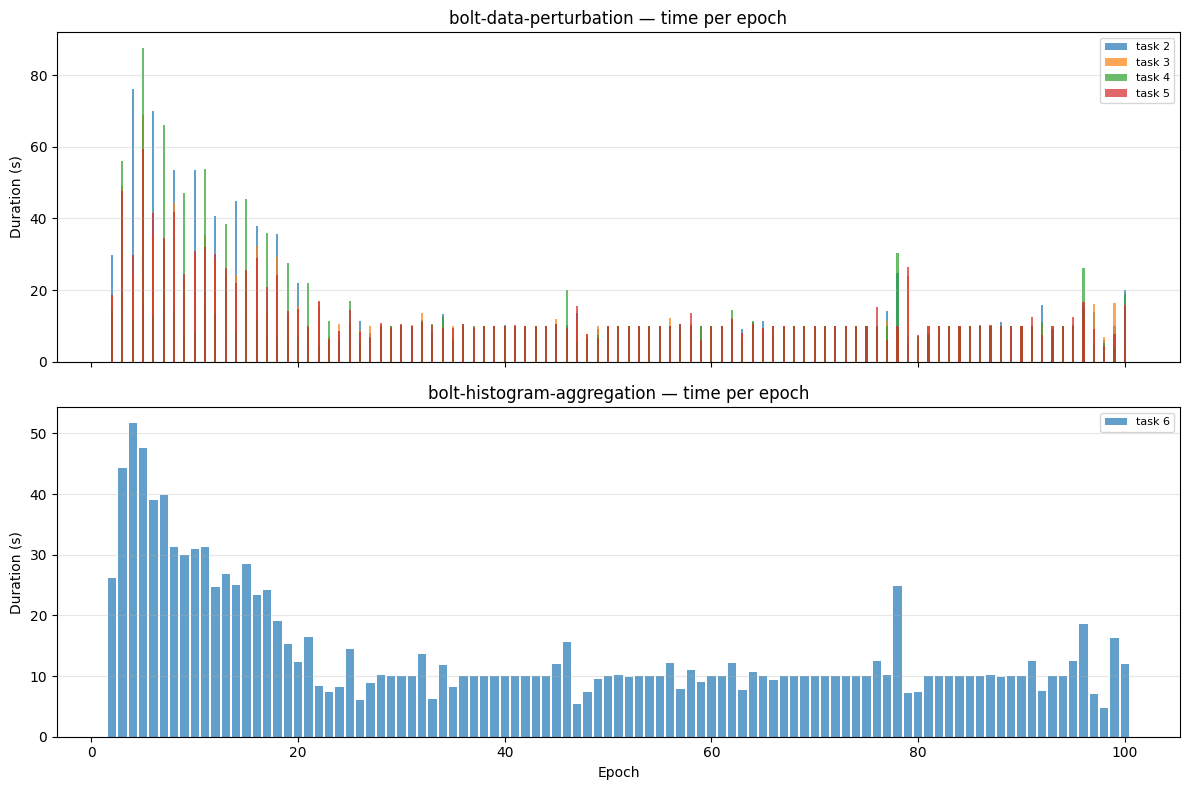


Snapshot computation durations (SNAPSHOT_STARTED → SNAPSHOT_COMPLETED):

  task 2: avg=5.9s, min=0.0s, max=50.1s
  task 3: avg=5.9s, min=1.3s, max=39.5s
  task 4: avg=6.0s, min=1.6s, max=45.0s
  task 5: avg=5.9s, min=2.0s, max=38.7s


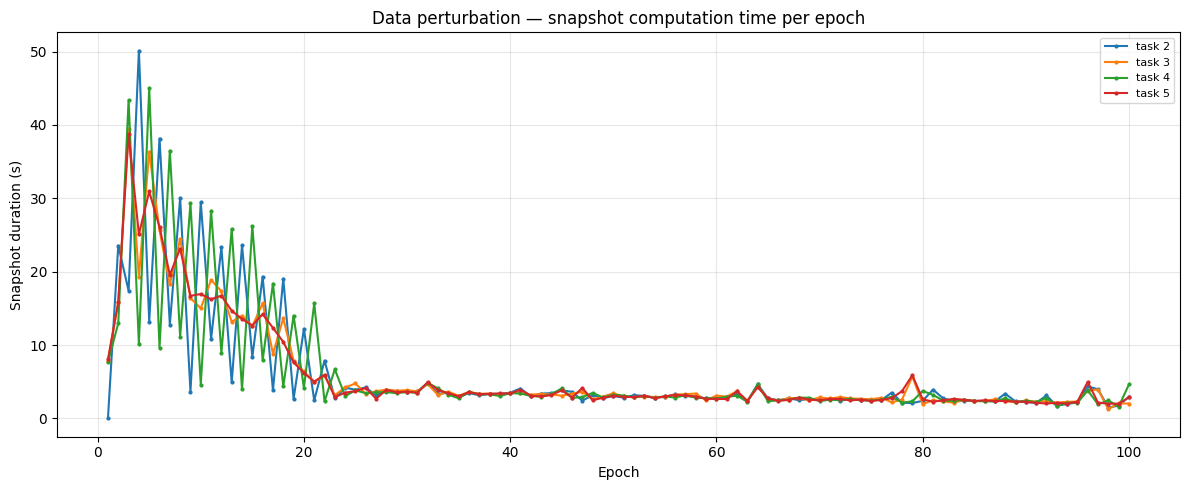


MAX_EPOCH_REACHED events:
  bolt-data-perturbation (task 2): epoch 100 at 1436.8s
  bolt-data-perturbation (task 3): epoch 100 at 1429.1s
  bolt-data-perturbation (task 4): epoch 100 at 1429.5s
  bolt-data-perturbation (task 5): epoch 100 at 1431.2s
  bolt-histogram-aggregation (task 6): epoch 100 at 1436.8s


In [103]:
epoch_events = lifecycle[lifecycle["event"].isin(["EPOCH_ADVANCED", "SNAPSHOT_STARTED", "SNAPSHOT_COMPLETED", "MAX_EPOCH_REACHED"])]

if epoch_events.empty:
    print("No epoch lifecycle events found — skipping epoch duration analysis")
else:
    # --- Epoch duration per component/task ---
    epoch_adv = epoch_events[epoch_events["event"] == "EPOCH_ADVANCED"].copy()

    if not epoch_adv.empty:
        print("Epoch durations (time between consecutive EPOCH_ADVANCED events):\n")
        components = sorted(epoch_adv["component"].unique())

        fig, axes = plt.subplots(len(components), 1, figsize=(12, 4 * len(components)),
                                 sharex=True, squeeze=False)
        for idx, comp in enumerate(components):
            ax = axes[idx, 0]
            comp_data = epoch_adv[epoch_adv["component"] == comp]
            tasks = sorted(comp_data["taskId"].unique())

            for i, task in enumerate(tasks):
                td = comp_data[comp_data["taskId"] == task].sort_values("epoch")
                durations = td["elapsed_s"].diff()
                ax.bar(td["epoch"].iloc[1:], durations.iloc[1:],
                       label=f"task {task}", color=color_for(i), alpha=0.7, width=0.8 / len(tasks))

                avg_dur = durations.iloc[1:].mean()
                print(f"  {comp} (task {task}): avg={avg_dur:.1f}s, "
                      f"min={durations.iloc[1:].min():.1f}s, max={durations.iloc[1:].max():.1f}s "
                      f"({len(td)} epochs)")

            ax.set_ylabel("Duration (s)")
            ax.set_title(f"{comp} — time per epoch")
            ax.legend(fontsize=8)
            ax.grid(True, axis="y", alpha=0.3)

        axes[-1, 0].set_xlabel("Epoch")
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, "epoch-duration", PLOT_FORMAT, True)

    # --- Snapshot computation time (perturbation bolt only) ---
    snap_start = epoch_events[epoch_events["event"] == "SNAPSHOT_STARTED"].copy()
    snap_end = epoch_events[epoch_events["event"] == "SNAPSHOT_COMPLETED"].copy()

    if not snap_start.empty and not snap_end.empty:
        print("\nSnapshot computation durations (SNAPSHOT_STARTED → SNAPSHOT_COMPLETED):\n")
        merged = snap_start.merge(snap_end, on=["component", "taskId", "epoch"],
                                  suffixes=("_start", "_end"))
        merged["snap_duration_s"] = merged["elapsed_s_end"] - merged["elapsed_s_start"]

        tasks = sorted(merged["taskId"].unique())
        fig, ax = plt.subplots(figsize=(12, 5))
        for i, task in enumerate(tasks):
            td = merged[merged["taskId"] == task].sort_values("epoch")
            ax.plot(td["epoch"], td["snap_duration_s"],
                    label=f"task {task}", color=color_for(i), linewidth=1.5, marker=".", markersize=4)
            avg_snap = td["snap_duration_s"].mean()
            print(f"  task {task}: avg={avg_snap:.1f}s, "
                  f"min={td['snap_duration_s'].min():.1f}s, max={td['snap_duration_s'].max():.1f}s")

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Snapshot duration (s)")
        ax.set_title("Data perturbation — snapshot computation time per epoch")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, "snapshot-duration", PLOT_FORMAT, True)

    # --- MAX_EPOCH_REACHED ---
    max_epoch = epoch_events[epoch_events["event"] == "MAX_EPOCH_REACHED"]
    if not max_epoch.empty:
        print("\nMAX_EPOCH_REACHED events:")
        for _, row in max_epoch.iterrows():
            print(f"  {row['component']} (task {int(row['taskId'])}): epoch {int(row['epoch'])} at {row['elapsed_s']:.1f}s")

After `MAX_EPOCH_REACHED`, both `DataPerturbationBolts` and `HistogramAggreagationBolts` stop recording profiler metrics. However, the other components do not have this mechanism and continue to record metrics until the topology is shutdown (this is by design, as they are not aware of the state of the DP bolts).

For this reason, rather than filtering out data after `MAX_EPOCH_REACHED`, plots show a vertical line at the timestamp of this event, to indicate when the DP bolts stop recording metrics. This allows us to see how the other components behave after the DP bolts have stopped, and whether there are any performance issues that arise after this point.

In [104]:
# calculate the timestamp of MAX_EPOCH_REACHED to add a vertical line in the plots (used in the next cells)
max_epoch = epoch_events[epoch_events["event"] == "MAX_EPOCH_REACHED"]["elapsed_s"].max()

## Plot 1: ECALL Latency Over Time

Shows the latency of each ECALL over time, allowing us to see how the latency changes as the system runs. 

This can help identify any trends or patterns over time. We expect to see a drop in `getSnapshot` latency in further epochs, as the *empty key prediction* algorithm needs to scan a shorter horizon (REMINDER: we only scan from the current time-step to `MAX_TIME_STEP`).

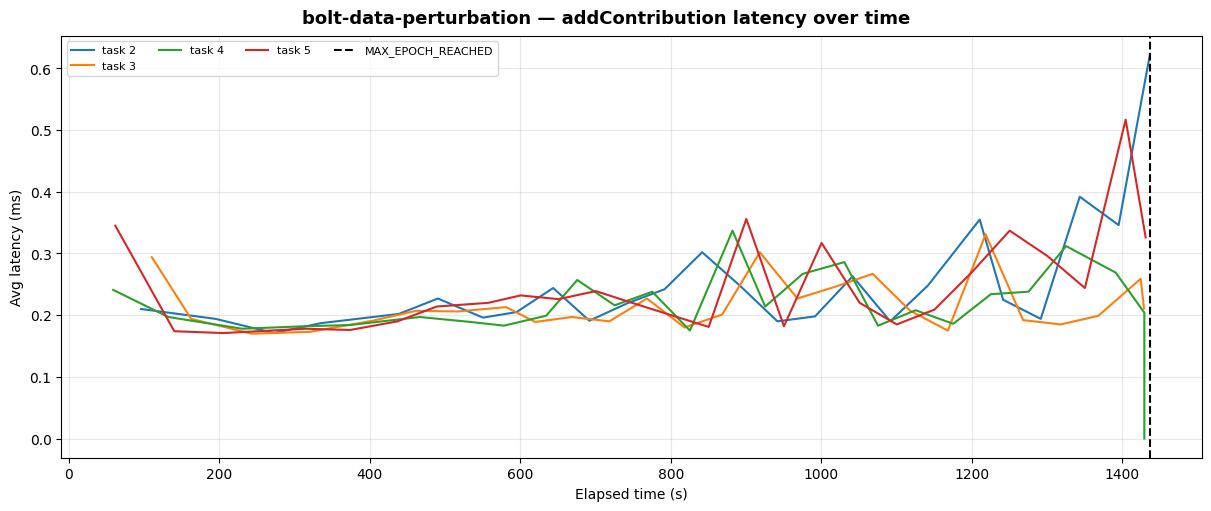

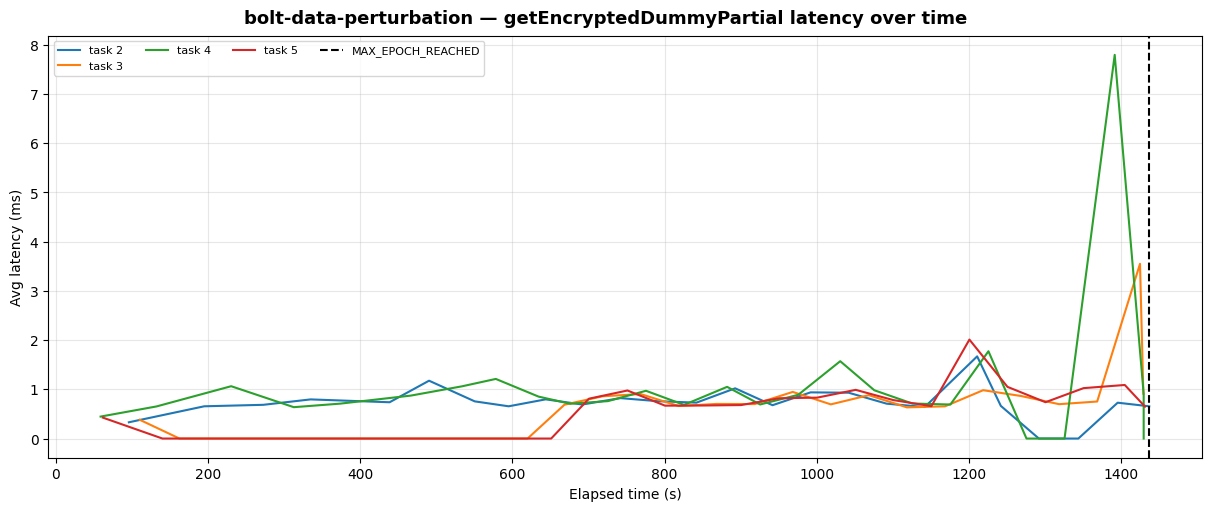

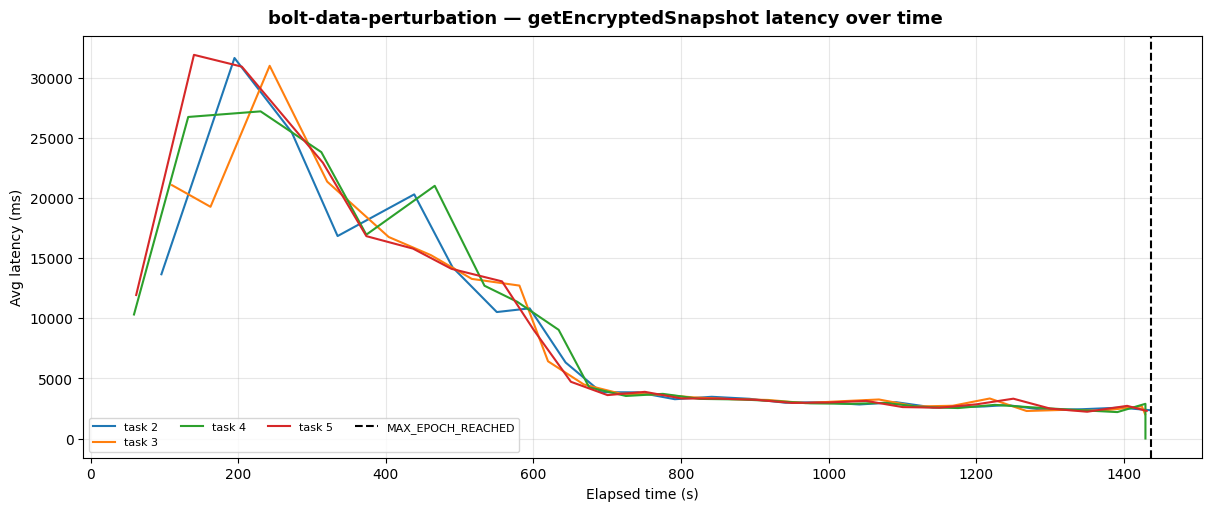

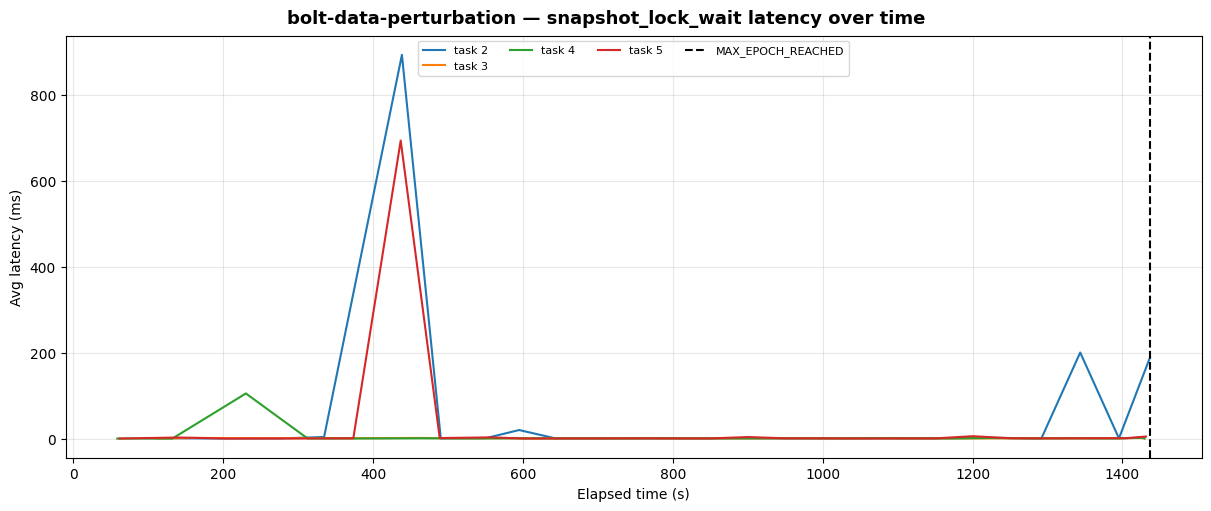

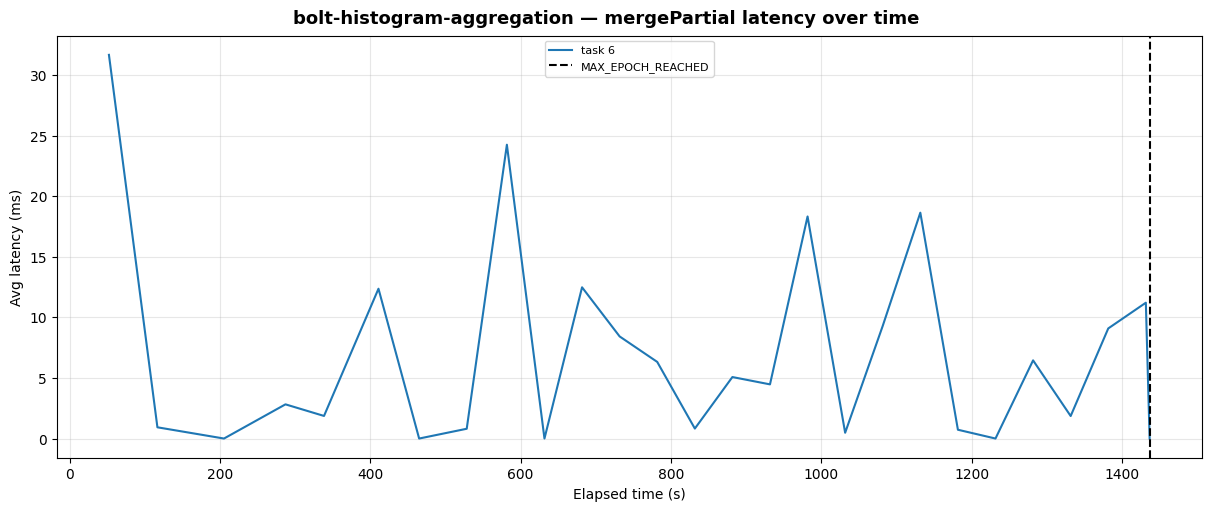

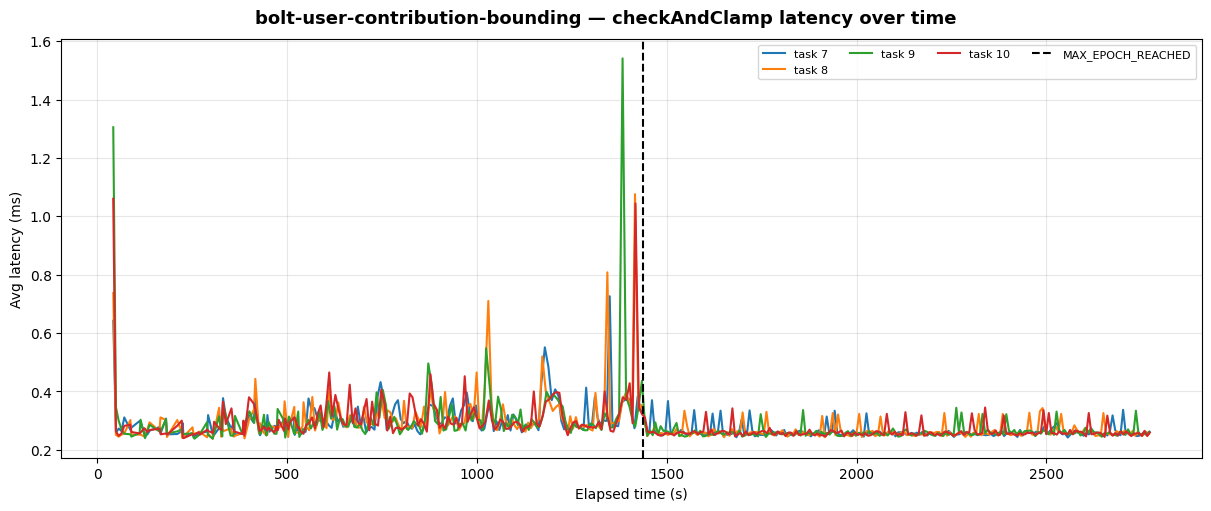

In [105]:
ecalls = df[df["type"] == "ecall"]
if not ecalls.empty:
    components = _get_components(ecalls)

    for comp in components:
        comp_data = ecalls[ecalls["component"] == comp]
        ecall_names = _get_ecall_names(ecalls, comp)

        for ecall_name in ecall_names:
            ed = comp_data[comp_data["name"] == ecall_name]
            tasks = sorted(ed["taskId"].unique())
            n_tasks = len(tasks)

            fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
            for i, task in enumerate(tasks):
                td = ed[ed["taskId"] == task].sort_values("elapsed_s")
                ax.plot(td["elapsed_s"], td["avgMs"],
                        label=f"task {task}", color=color_for(i), linewidth=1.5)
                
            # show vertical line for MAX_EPOCH_REACHED
            if max_epoch is not None and not np.isnan(max_epoch):
                ax.axvline(max_epoch, color=MAX_EPOCH_COLOR, linestyle="--", label="MAX_EPOCH_REACHED")

            ax.set_ylabel("Avg latency (ms)")
            ax.legend(fontsize=8, ncol=min(n_tasks, 6))
            ax.grid(True, alpha=0.3)
            format_elapsed_axis(ax)
            fig.suptitle(f"{comp} — {ecall_name} latency over time", fontsize=13, fontweight="bold")
            save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"latency-{comp}-{ecall_name}", PLOT_FORMAT, True)

## Plot 2: ECALL Latency Distribution (Box Plots)

Distribution of average latency per ECALL within each component. 

This helps identify which ECALLs have the highest latency and variability.

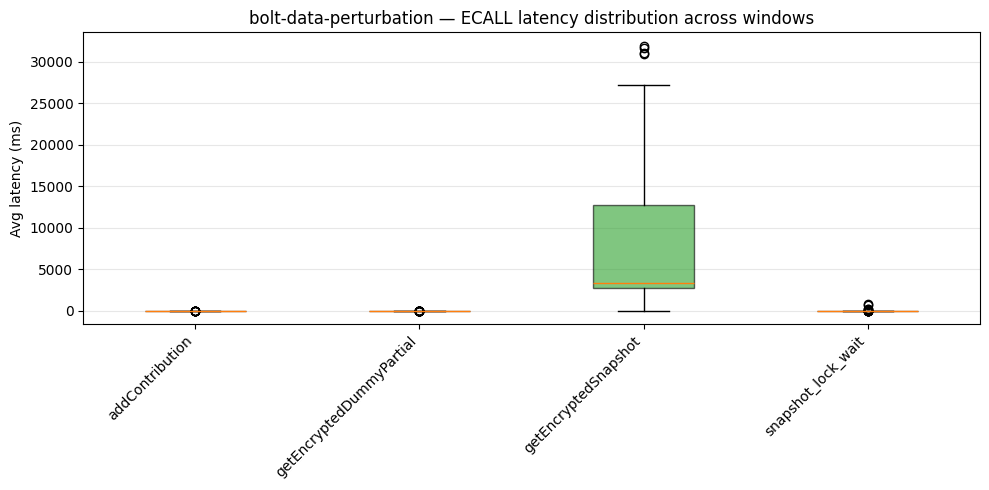

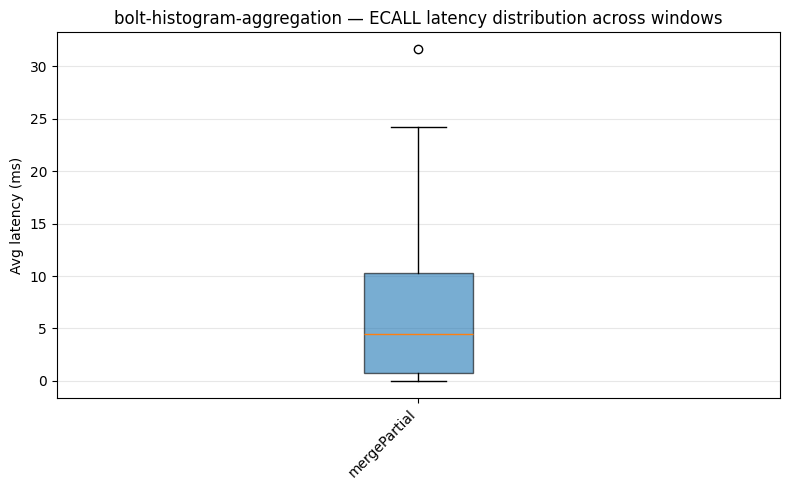

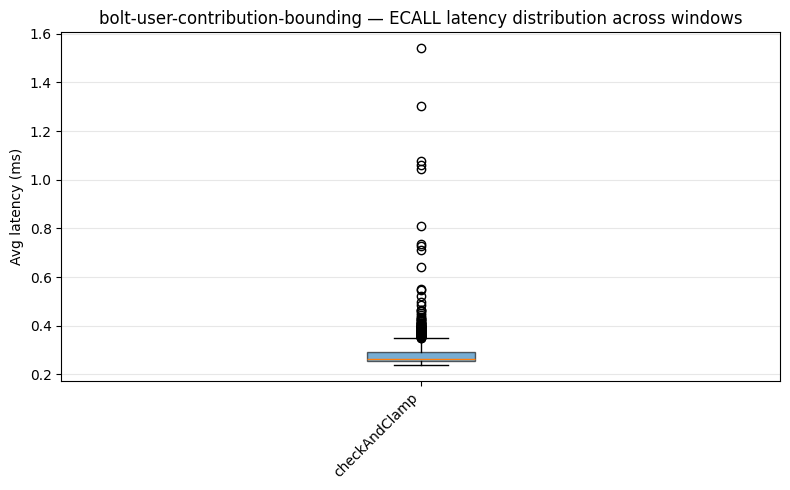

In [106]:
ecalls = df[df["type"] == "ecall"]
if not ecalls.empty:
    components = _get_components(ecalls)

    for comp in components:
        comp_data = ecalls[ecalls["component"] == comp]
        ecall_names = _get_ecall_names(ecalls, comp)

        data_for_box = []
        labels = []
        for en in ecall_names:
            vals = comp_data.loc[comp_data["name"] == en, "avgMs"].dropna()
            if not vals.empty:
                data_for_box.append(vals.values)
                labels.append(en)

        if not data_for_box:
            continue

        fig, ax = plt.subplots(figsize=(max(8, len(labels) * 2.5), 5))
        bp = ax.boxplot(data_for_box, tick_labels=labels, patch_artist=True)
        for i, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(color_for(i))
            patch.set_alpha(0.6)
        ax.set_ylabel("Avg latency (ms)")
        ax.set_title(f"{comp} — ECALL latency distribution across windows")
        ax.grid(True, axis="y", alpha=0.3)
        plt.xticks(rotation=45, ha="right")
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"boxplot-{comp}", PLOT_FORMAT, True)

## Plot 3: Throughput Over Time

Total invocations per second, summed across all tasks.

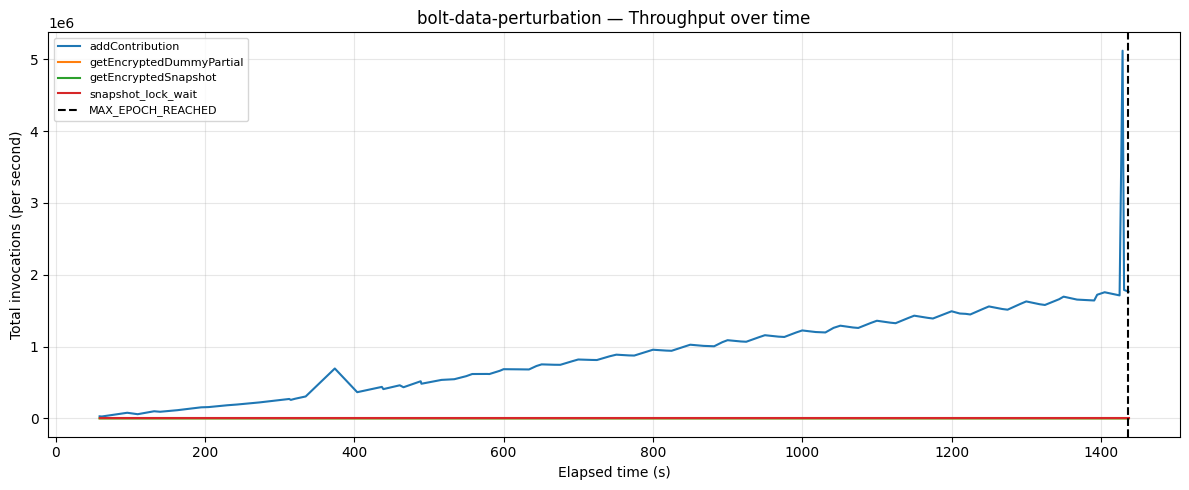

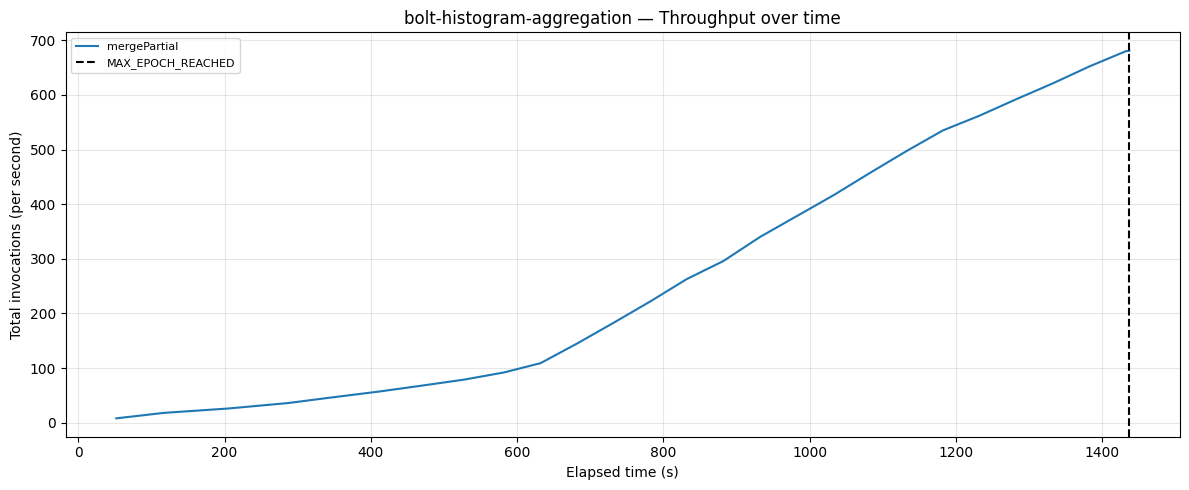

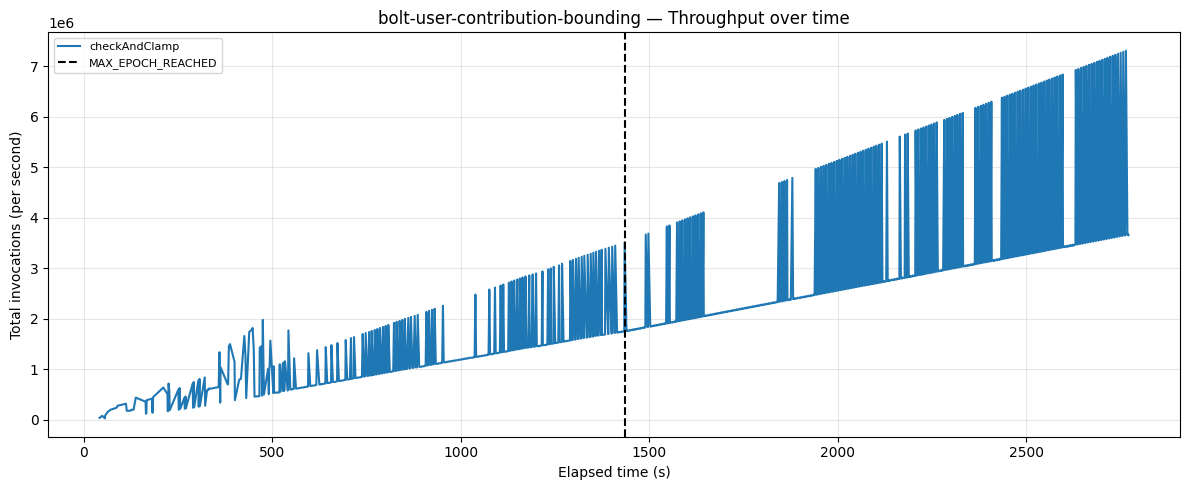

In [107]:
ecalls = df[df["type"] == "ecall"]
if not ecalls.empty:
    components = _get_components(ecalls)

    for comp in components:
        comp_data = ecalls[ecalls["component"] == comp]
        ecall_names = _get_ecall_names(ecalls, comp)

        fig, ax = plt.subplots(figsize=(12, 5))
        for i, en in enumerate(ecall_names):
            ed = comp_data[comp_data["name"] == en]
            grouped = ed.groupby(ed["elapsed_s"].round())["total"].sum().sort_index()
            ax.plot(grouped.index, grouped.to_numpy(), label=en, color=color_for(i), linewidth=1.5)

        if max_epoch is not None and not np.isnan(max_epoch):
            ax.axvline(max_epoch, color=MAX_EPOCH_COLOR, linestyle="--", label="MAX_EPOCH_REACHED")
        
        ax.set_ylabel("Total invocations (per second)")
        ax.set_title(f"{comp} — Throughput over time")
        format_elapsed_axis(ax)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"throughput-{comp}", PLOT_FORMAT, True)

## Plot 4: Counter Evolution Over Time

Tracks counter metrics per task over time. Counters are **cumulative** — they monotonically increase throughout the topology's lifetime.

### Counters by component

**`bolt-user-contribution-bounding`**
- **`dropped`**: Number of tuples dropped because the user exceeded their contribution limit (per-user bounding).
- **`forwarded`**: Number of tuples that passed the contribution check and were forwarded to the next bolt.

**`bolt-data-perturbation`**
- **`real_emissions`**: Number of real (non-dummy) partial histograms emitted after a successful `getEncryptedSnapshot()` call. Incremented once per completed epoch.
- **`dummy_emissions`**: Number of dummy partials emitted while the background snapshot computation is still in progress. These are discarded by the downstream aggregation bolt.

**`bolt-histogram-aggregation`**
- **`real_partials_received`**: Number of real (non-dummy) partial histograms received from upstream perturbation replicas and merged.
- **`dummies_received`**: Number of dummy partials received and discarded.
- **`histograms_released`**: Number of complete merged histograms released on a tick (i.e., a new histogram was ready since the last tick).
- **`stale_releases`**: Number of ticks where no new histogram was available, so the previous one was re-released as stale.

In [ ]:
counters = df[df["type"] == "counter"]
if not counters.empty:
    components = _get_components(counters)

    for comp in components:
        comp_data = counters[counters["component"] == comp]
        counter_names = sorted(comp_data["name"].unique())
        if not counter_names:
            continue

        tasks = sorted(comp_data["taskId"].unique())
        n_counters = len(counter_names)
        fig, axes = plt.subplots(n_counters, 1, figsize=(12, 3.5 * n_counters), sharex=True,
                                 squeeze=False)
        for i, cn in enumerate(counter_names):
            ax = axes[i, 0]
            cd = pd.DataFrame, comp_data[comp_data["name"] == cn]
            for j, task in enumerate(tasks):
                cd = cd[1] if isinstance(cd, tuple) else cd
                td = cd[cd["taskId"] == task].sort_values("elapsed_s")
                lbl = f"task {task}" if len(tasks) > 1 else cn
                ax.plot(td["elapsed_s"], td["total"], label=lbl,
                        color=color_for(j), linewidth=1.5, marker=".", markersize=3)

            if max_epoch is not None and not np.isnan(max_epoch):
                ax.axvline(max_epoch, color=MAX_EPOCH_COLOR, linestyle="--", label="MAX_EPOCH_REACHED")

            ax.set_ylabel(cn)
            ax.legend(fontsize=7, ncol=min(len(tasks), 4))
            ax.grid(True, alpha=0.3)

        axes[0, 0].set_title(f"{comp} — Counters over time")
        format_elapsed_axis(axes[-1, 0])
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"counters-{comp}", PLOT_FORMAT, True)

## Plot 5: Gauge Evolution Over Time

Tracks gauge metrics per task over time. In this context, **gauges are point-in-time values that reset each epoch** — unlike counters (which are cumulative), gauges capture a snapshot of some quantity at the moment the epoch completes.

### Gauges by component

**`bolt-data-perturbation`**
- **`epoch_lag`**: Difference between the global target epoch (from ZooKeeper) and the replica's local epoch. A value > 1 means this replica is falling behind. Ideally stays at 0 or 1.
- **`contributions_this_epoch`**: Number of `addContribution()` calls processed by this replica during the current epoch, reset to 0 when the epoch advances. Useful for checking load balance across replicas.

**`bolt-histogram-aggregation`**
- **`ticks_to_completion`**: Number of tick intervals elapsed between consecutive epoch completions. Measures how long the aggregation bolt waited before receiving all real partials for an epoch.
- **`dummy_merges_this_epoch`**: Number of dummy partials merged (and discarded) during the current epoch, reset when the epoch completes.
- **`real_merges_this_epoch`**: Number of real partials merged during the current epoch, reset when the epoch completes. Should equal the number of upstream perturbation replicas when the epoch is complete.
- **`total_merges_this_epoch`**: Sum of dummy and real merges for the current epoch (`dummy_merges_this_epoch + real_merges_this_epoch`). Indicates total merge load per epoch.

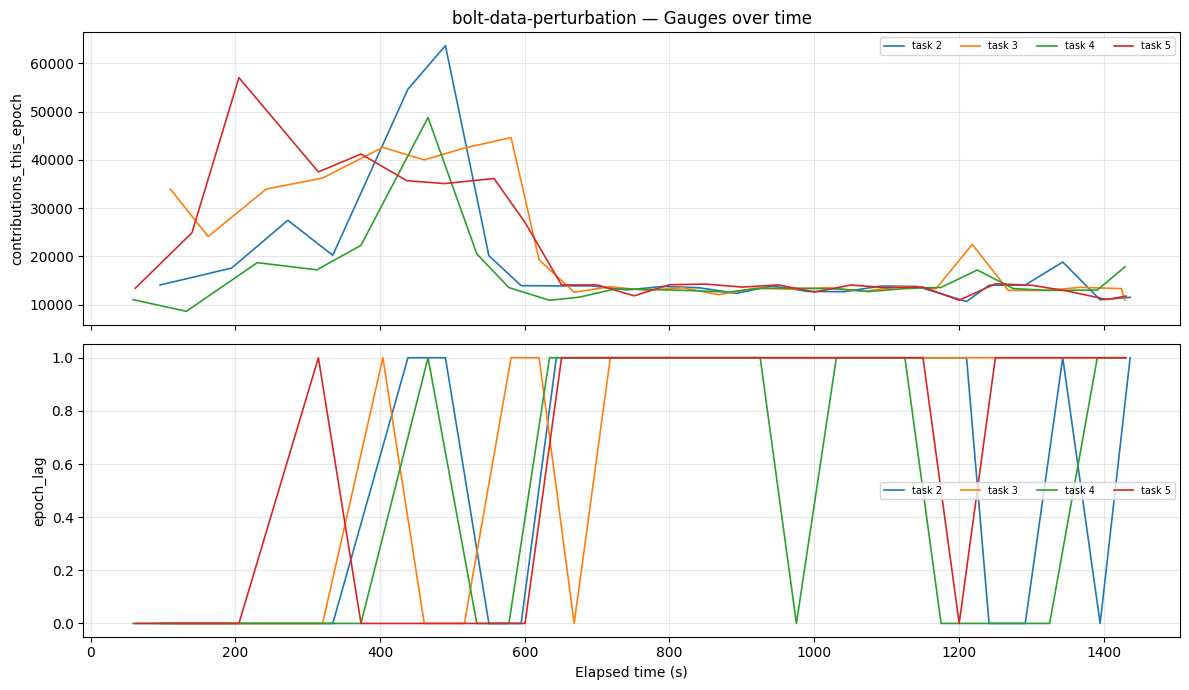

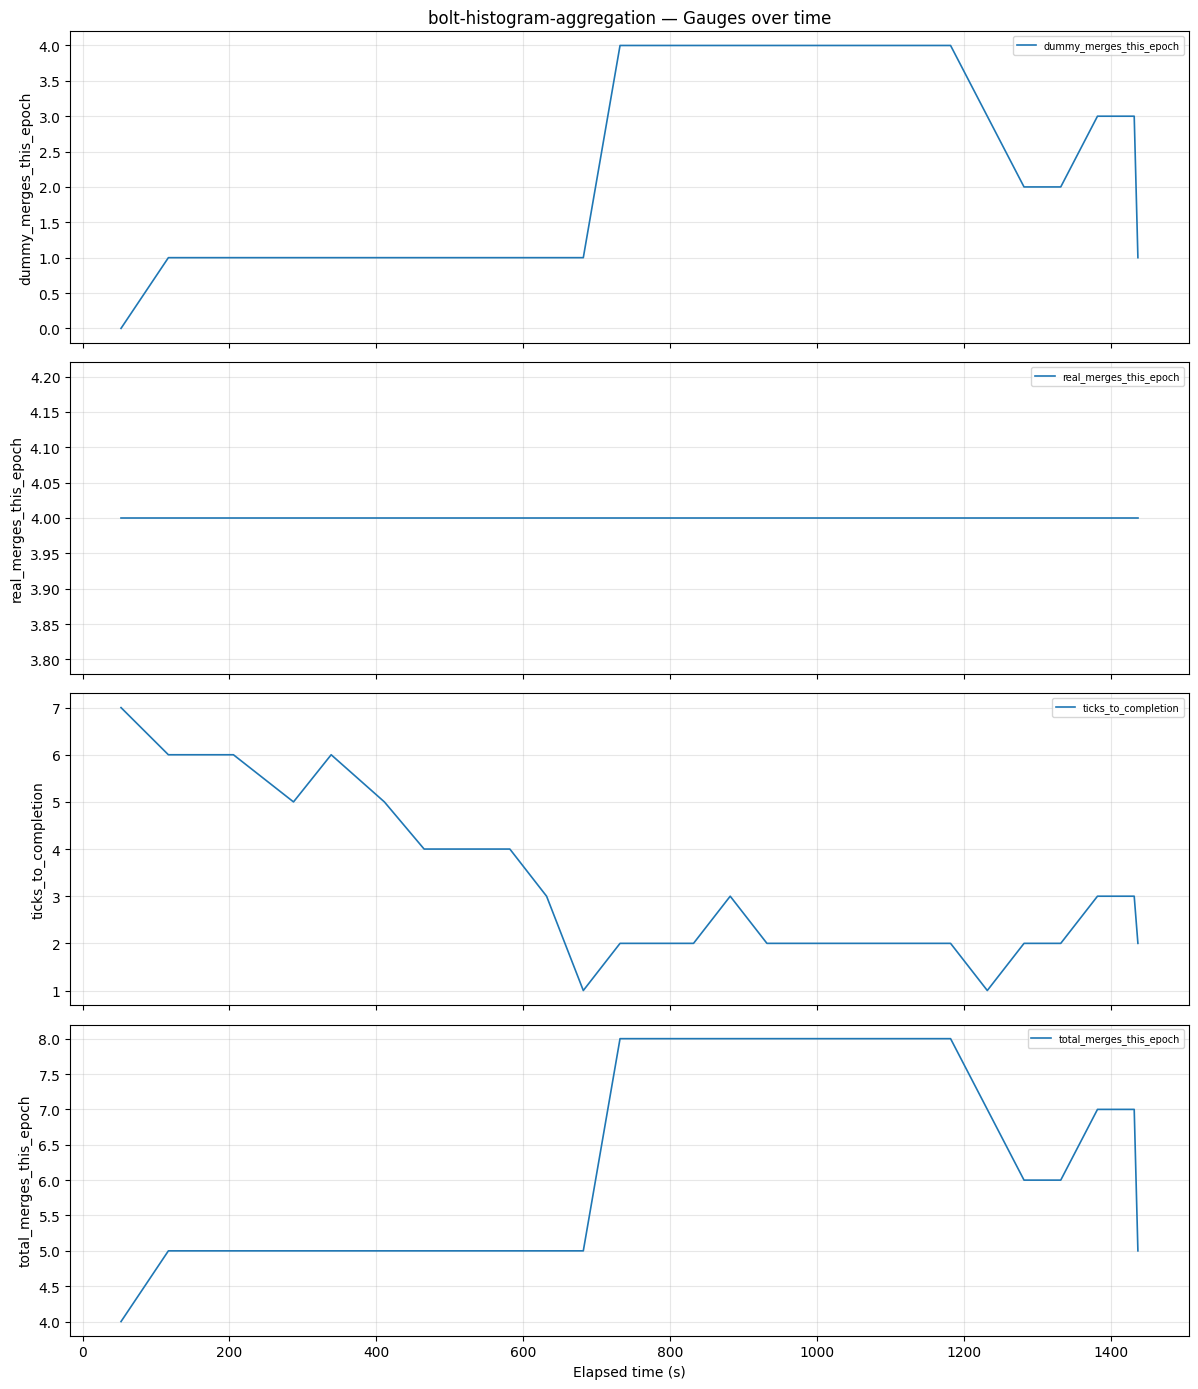

In [ ]:
gauges = cast(pd.DataFrame, df[df["type"] == "gauge"])
if not gauges.empty:
    components = _get_components(gauges)

    for comp in components:
        comp_data = cast(pd.DataFrame, gauges[gauges["component"] == comp])
        gauge_names = sorted(comp_data["name"].unique())
        if not gauge_names:
            continue

        n_gauges = len(gauge_names)
        fig, axes = plt.subplots(n_gauges, 1, figsize=(12, 3.5 * n_gauges), sharex=True,
                                 squeeze=False)
        for i, gn in enumerate(gauge_names):
            ax = axes[i, 0]
            gd = cast(pd.DataFrame, comp_data[comp_data["name"] == gn])
            tasks = sorted(gd["taskId"].unique())
            for j, task in enumerate(tasks):
                td = cast(pd.DataFrame, gd[gd["taskId"] == task]).sort_values("elapsed_s")
                lbl = f"task {task}" if len(tasks) > 1 else gn
                ax.plot(td["elapsed_s"], td["total"], label=lbl,
                        color=color_for(j), linewidth=1.2)
            ax.set_ylabel(gn)
            ax.legend(fontsize=7, ncol=min(len(tasks), 4))
            ax.grid(True, alpha=0.3)

        axes[0, 0].set_title(f"{comp} — Gauges over time")
        format_elapsed_axis(axes[-1, 0])
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"gauges-{comp}", PLOT_FORMAT, True)

## Plot 6: Task Imbalance Comparison

Side-by-side comparison of ECALL latency distribution and throughput across tasks, plus counter values per task. Only generated when multiple tasks exist.

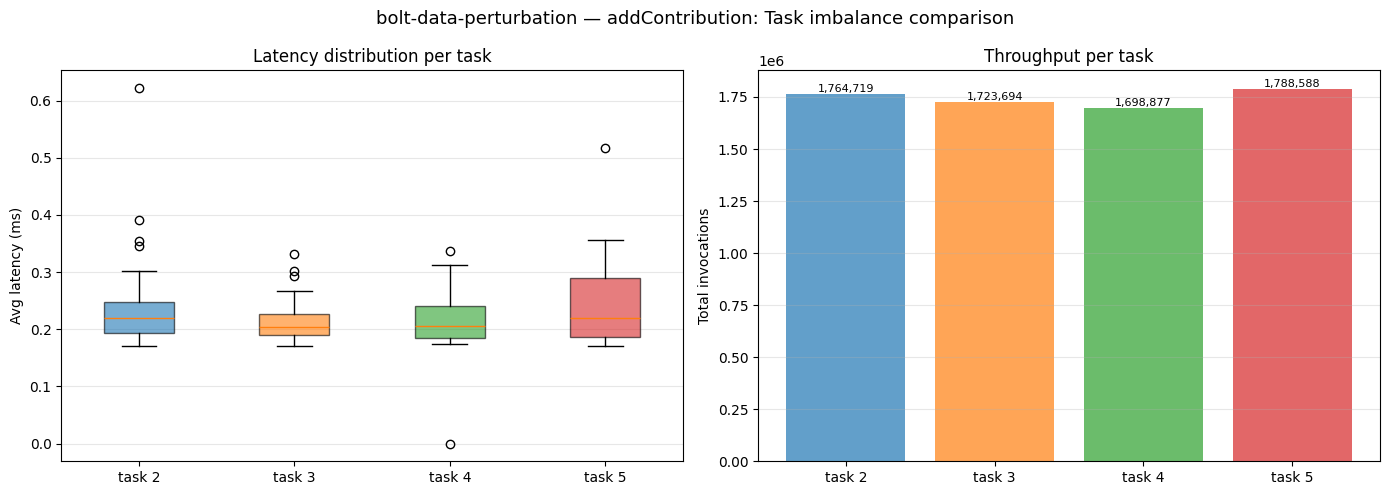

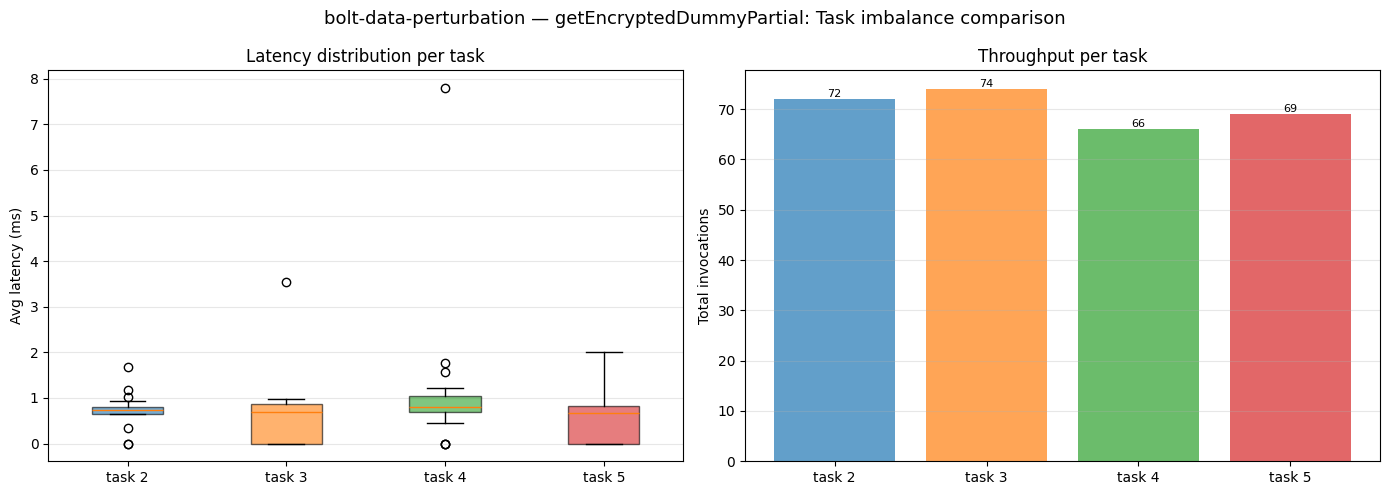

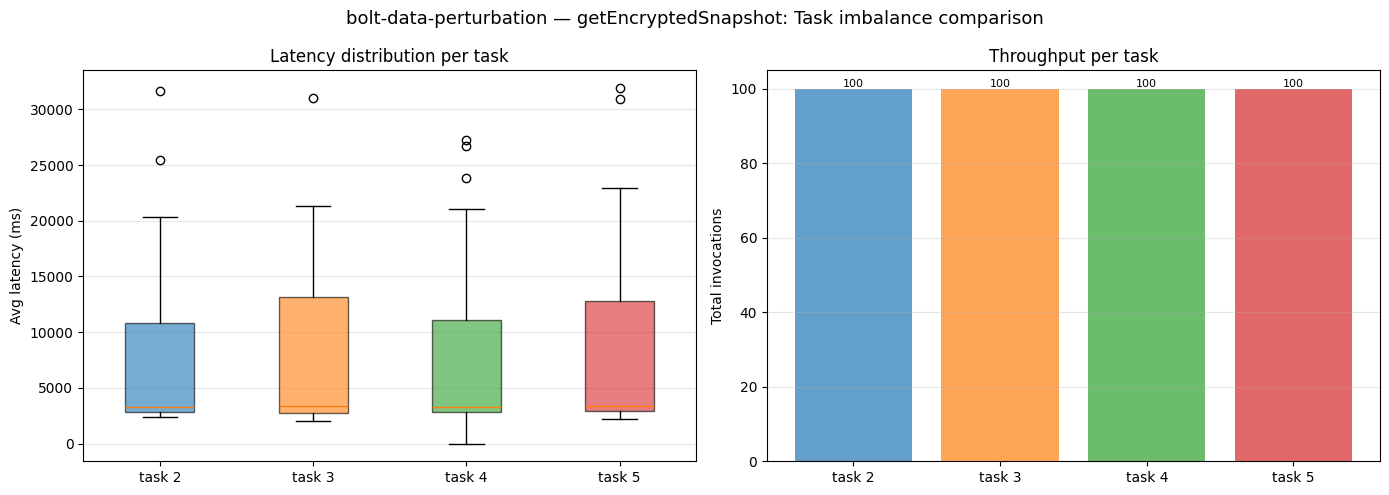

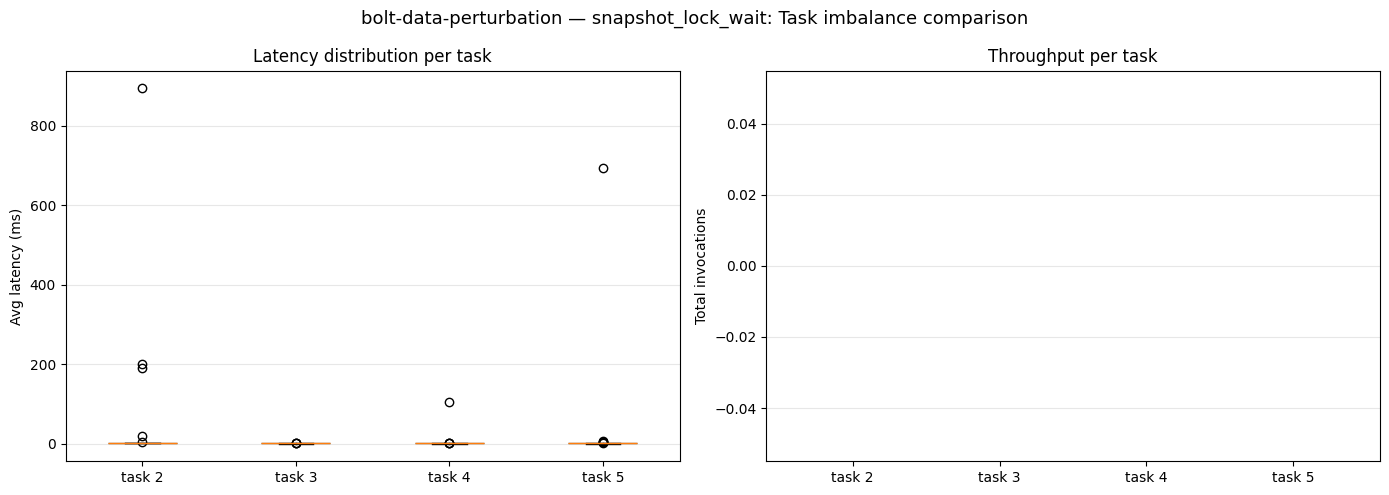

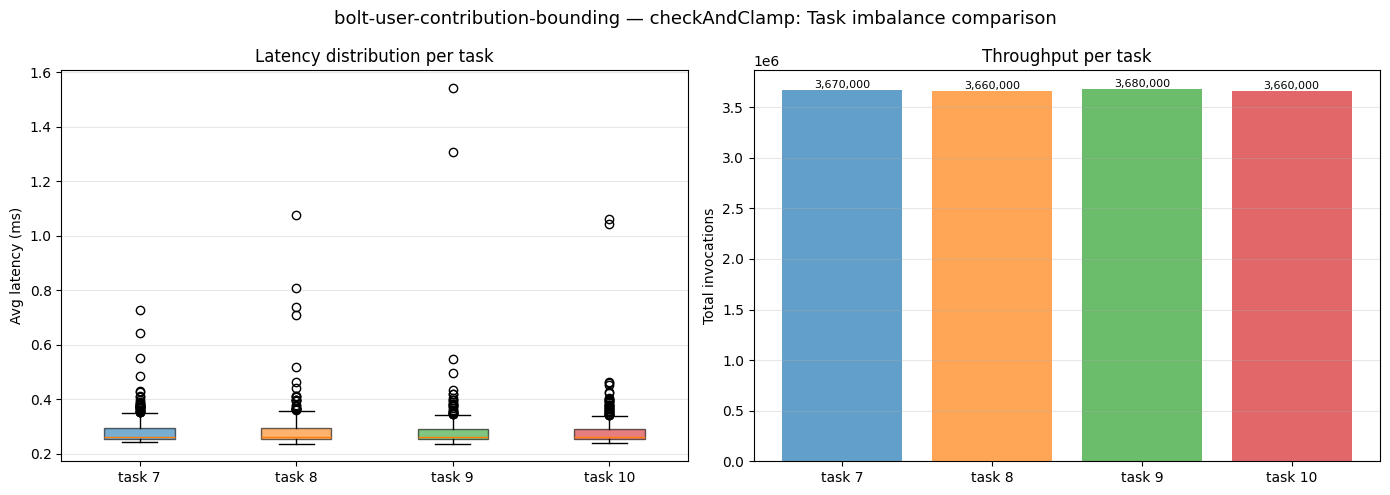

In [ ]:
ecalls = cast(pd.DataFrame, df[df["type"] == "ecall"])
if not ecalls.empty:
    components = _get_components(ecalls)

    for comp in components:
        comp_data = cast(pd.DataFrame, ecalls[ecalls["component"] == comp])
        tasks = sorted(comp_data["taskId"].unique())
        if len(tasks) < 2:
            continue

        ecall_names = _get_ecall_names(ecalls, comp)

        for en in ecall_names:
            ed = cast(pd.DataFrame, comp_data[comp_data["name"] == en])

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

            # Left: avg latency per task (box plot)
            task_latencies = []
            task_labels = []
            for t in tasks:
                vals = ed.loc[ed["taskId"] == t, "avgMs"].dropna()
                if not vals.empty:
                    task_latencies.append(vals.values)
                    task_labels.append(f"task {t}")

            if task_latencies:
                bp = ax1.boxplot(task_latencies, tick_labels=task_labels, patch_artist=True)
                for i, patch in enumerate(bp["boxes"]):
                    patch.set_facecolor(color_for(i))
                    patch.set_alpha(0.6)
            ax1.set_ylabel("Avg latency (ms)")
            ax1.set_title("Latency distribution per task")
            ax1.grid(True, axis="y", alpha=0.3)

            # Right: total invocations per task (bar chart)
            task_totals = []
            for t in tasks:
                td = cast(pd.DataFrame, ed[ed["taskId"] == t])
                task_totals.append(int(td["total"].max()) if not td.empty else 0)

            bars = ax2.bar([f"task {t}" for t in tasks], task_totals,
                           color=[color_for(i) for i in range(len(tasks))], alpha=0.7)
            ax2.set_ylabel("Total invocations")
            ax2.set_title("Throughput per task")
            ax2.grid(True, axis="y", alpha=0.3)
            for bar, val in zip(bars, task_totals):
                if val > 0:
                    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                             f"{val:,.0f}", ha="center", va="bottom", fontsize=8)

            fig.suptitle(f"{comp} — {en}: Task imbalance comparison", fontsize=13)
            save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"imbalance-{comp}-{en}", PLOT_FORMAT, True)

## Plot 7: Counter Imbalance Across Tasks

Compares final (cumulative) counter values across tasks within each component. Only generated when multiple tasks exist. Helps detect uneven load distribution — e.g., one perturbation replica dropping more contributions than others.

NOTE: in plot 4 we can see that `contribution-bounding-bolt` starts to get a significant number of drops way after the DP bolts have stopped recording metrics (after `MAX_EPOCH_REACHED`). Since I show both `dropped` and `forwarded` contributions with the same y-axis (the latter has a much higher magnitude), the `dropped` counter seems to be 0. Just something to keep in mind when interpreting the plot.

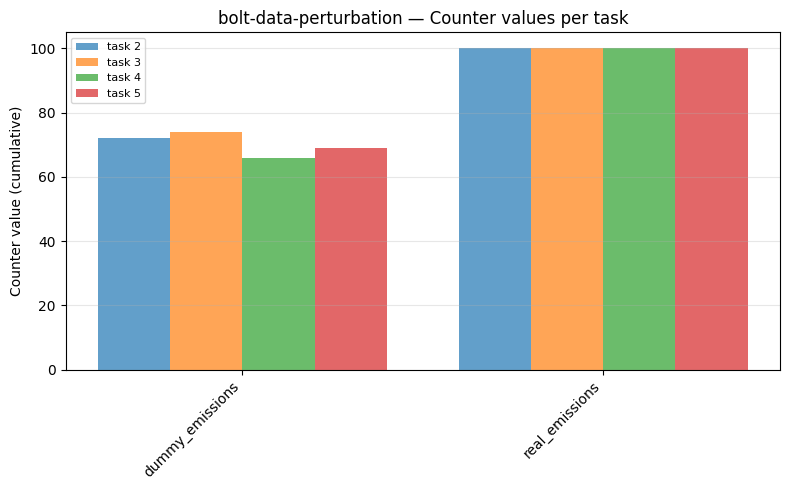

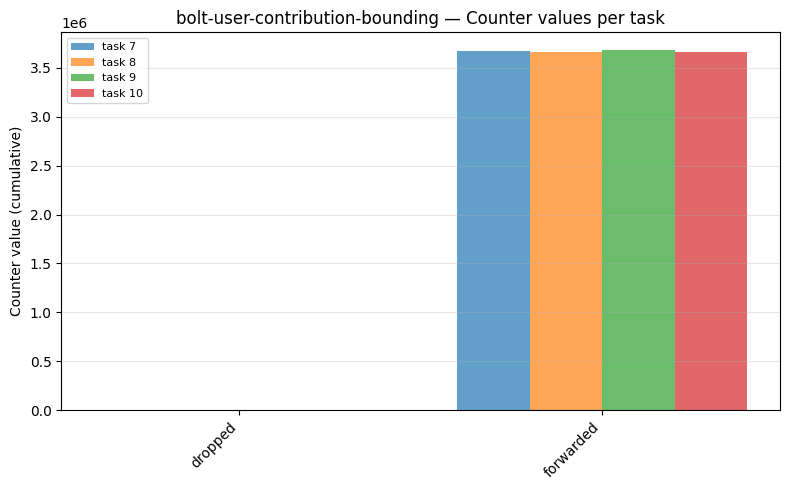

In [ ]:
counters = cast(pd.DataFrame, df[df["type"] == "counter"])
if not counters.empty:
    components = _get_components(counters)

    for comp in components:
        comp_counters = cast(pd.DataFrame, counters[counters["component"] == comp])
        tasks = sorted(comp_counters["taskId"].unique())
        if len(tasks) < 2:
            continue

        counter_names = sorted(comp_counters["name"].unique())
        if not counter_names:
            continue

        fig, ax = plt.subplots(figsize=(max(8, len(counter_names) * 2), 5))
        bar_width = 0.8 / len(tasks)
        x = np.arange(len(counter_names))

        for i, t in enumerate(tasks):
            td = cast(pd.DataFrame, comp_counters[comp_counters["taskId"] == t])
            vals = []
            for cn in counter_names:
                v = td.loc[td["name"] == cn, "total"]
                vals.append(int(v.max()) if not v.empty else 0)
            ax.bar(x + i * bar_width, vals, bar_width, label=f"task {t}",
                   color=color_for(i), alpha=0.7)

        ax.set_xticks(x + bar_width * (len(tasks) - 1) / 2)
        ax.set_xticklabels(counter_names, rotation=45, ha="right")
        ax.set_ylabel("Counter value (cumulative)")
        ax.set_title(f"{comp} — Counter values per task")
        ax.legend(fontsize=8)
        ax.grid(True, axis="y", alpha=0.3)
        save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, f"imbalance-counters-{comp}", PLOT_FORMAT, True)

## Plot 8: Summary Dashboard

A table summarizing key metrics (avg/min/max latency, total calls, task count) across all components and ECALLs.

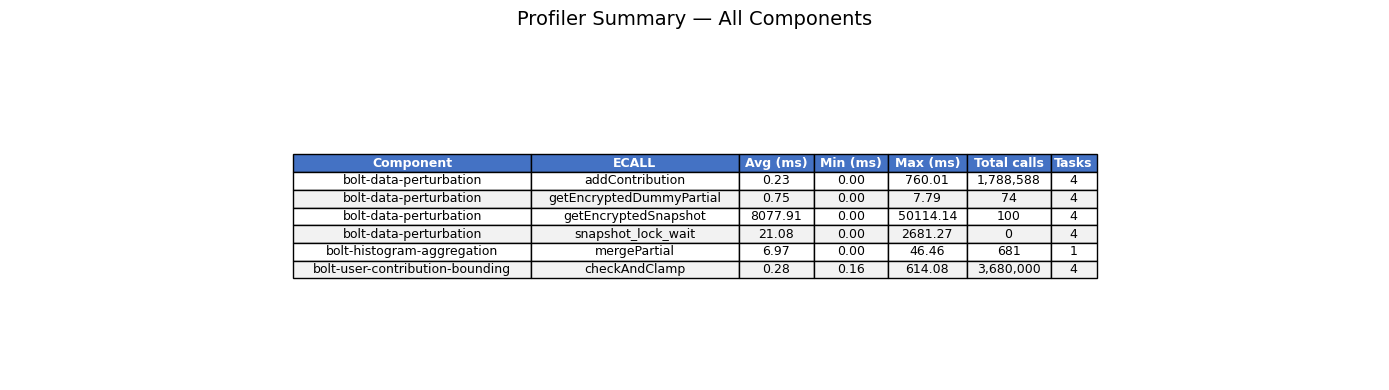

In [ ]:
ecalls = cast(pd.DataFrame, df[df["type"] == "ecall"])
components = _get_components(df)

rows = []
for comp in components:
    ce = cast(pd.DataFrame, ecalls[ecalls["component"] == comp])
    for en in sorted(ce["name"].unique()):
        ed = cast(pd.DataFrame, ce[ce["name"] == en])
        rows.append({
            "Component": comp,
            "ECALL": en,
            "Avg (ms)": f"{ed['avgMs'].mean():.2f}",
            "Min (ms)": f"{ed['minMs'].min():.2f}",
            "Max (ms)": f"{ed['maxMs'].max():.2f}",
            "Total calls": f"{int(ed['total'].max()):,}",
            "Tasks": len(ed["taskId"].unique()),
        })

if rows:
    summary = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(14, max(3, 1 + 0.5 * len(rows))))
    ax.axis("off")
    table = ax.table(
        cellText=summary.values.tolist(),
        colLabels=list(summary.columns),
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.auto_set_column_width(list(range(len(summary.columns))))
    # Style header
    for j in range(len(summary.columns)):
        table[(0, j)].set_facecolor("#4472C4")
        table[(0, j)].set_text_props(color="white", fontweight="bold")
    # Alternate row colors
    for i in range(1, len(rows) + 1):
        color = "#F2F2F2" if i % 2 == 0 else "white"
        for j in range(len(summary.columns)):
            table[(i, j)].set_facecolor(color)

    ax.set_title("Profiler Summary — All Components", fontsize=14, pad=20)
    save_or_show(fig, OUTPUT_DIR if SAVE_PLOTS else None, "summary-dashboard", PLOT_FORMAT, True)